In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def entropy(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    
    return -np.sum(probs * np.log2(probs))

In [3]:
print(entropy(np.array([0, 0, 0])))     # should be 0
print(entropy(np.array([0, 1, 0, 1])))  # higher value

-0.0
1.0


In [4]:
def information_gain(y, y_left, y_right):
    parent_entropy = entropy(y)
    
    n = len(y)
    n_left = len(y_left)
    n_right = len(y_right)
    
    weighted_entropy = (
        (n_left / n) * entropy(y_left) +
        (n_right / n) * entropy(y_right)
    )
    
    return parent_entropy - weighted_entropy

In [5]:
y = np.array([0, 1, 0, 1])

y_left = np.array([0, 0])
y_right = np.array([1, 1])

print(information_gain(y, y_left, y_right))  # should be high

1.0


In [6]:
def split(X, y, feature_index, threshold):
    left_mask = X[:, feature_index] < threshold
    right_mask = ~left_mask
    
    return (
        X[left_mask], y[left_mask],
        X[right_mask], y[right_mask]
    )

In [7]:
def best_split(X, y):
    best_gain = -1
    best_feature = None
    best_threshold = None
    
    n_features = X.shape[1]
    
    for feature in range(n_features):
        thresholds = np.unique(X[:, feature])
        
        for threshold in thresholds:
            X_l, y_l, X_r, y_r = split(X, y, feature, threshold)
            
            if len(y_l) == 0 or len(y_r) == 0:
                continue
            
            gain = information_gain(y, y_l, y_r)
            
            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold
    
    return best_feature, best_threshold

In [8]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape, y.shape)

(569, 30) (569,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

In [11]:
def build_tree(X, y, depth=0, max_depth=5):
    # Stop if pure or depth limit reached
    if len(np.unique(y)) == 1 or depth >= max_depth:
        return Node(value=np.bincount(y).argmax())
    
    feature, threshold = best_split(X, y)
    
    if feature is None:
        return Node(value=np.bincount(y).argmax())
    
    X_l, y_l, X_r, y_r = split(X, y, feature, threshold)
    
    left = build_tree(X_l, y_l, depth + 1, max_depth)
    right = build_tree(X_r, y_r, depth + 1, max_depth)
    
    return Node(feature, threshold, left, right)

In [12]:
def predict_single(x, node):
    if node.value is not None:
        return node.value
    
    if x[node.feature] < node.threshold:
        return predict_single(x, node.left)
    else:
        return predict_single(x, node.right)

In [13]:
def predict(X, tree):
    return np.array([predict_single(x, tree) for x in X])

In [14]:
tree = build_tree(X_train, y_train, max_depth=5)

y_pred = predict(X_test, tree)

In [15]:
acc = np.sum(y_pred == y_test) / len(y_test)
print("Accuracy:", acc)

Accuracy: 0.956140350877193


In [16]:
depths = list(range(1, 11))

train_accs = []
test_accs = []

for d in depths:
    tree = build_tree(X_train, y_train, max_depth=d)
    
    y_train_pred = predict(X_train, tree)
    y_test_pred = predict(X_test, tree)
    
    train_acc = np.sum(y_train_pred == y_train) / len(y_train)
    test_acc = np.sum(y_test_pred == y_test) / len(y_test)
    
    train_accs.append(train_acc)
    test_accs.append(test_acc)

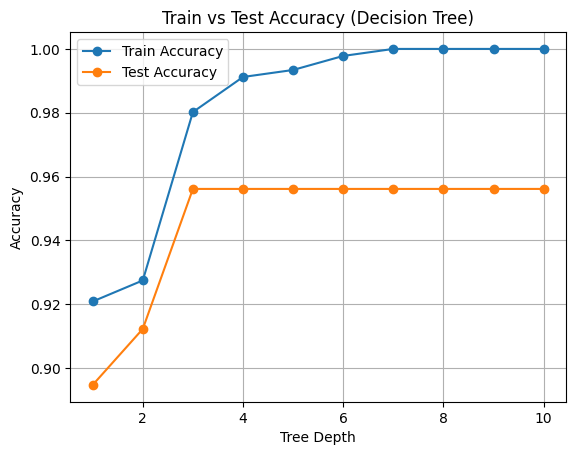

In [17]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(depths, train_accs, marker='o', label="Train Accuracy")
plt.plot(depths, test_accs, marker='o', label="Test Accuracy")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy (Decision Tree)")

plt.legend()
plt.grid()

plt.show()

In [18]:
def print_tree(node, depth=0):
    if node.value is not None:
        print("  " * depth + f"Leaf: Class {node.value}")
        return
    
    print("  " * depth + f"[X{node.feature} < {node.threshold}]")
    
    print_tree(node.left, depth + 1)
    print_tree(node.right, depth + 1)

In [19]:
print_tree(tree)

[X7 < 0.05182]
  [X20 < 16.89]
    [X10 < 0.645]
      [X21 < 30.25]
        Leaf: Class 1
        [X20 < 14.49]
          Leaf: Class 1
          [X0 < 13.46]
            [X1 < 30.72]
              Leaf: Class 0
              Leaf: Class 1
            Leaf: Class 1
      [X4 < 0.09387]
        Leaf: Class 1
        Leaf: Class 0
    [X1 < 16.68]
      Leaf: Class 1
      [X17 < 0.01033]
        Leaf: Class 0
        Leaf: Class 1
  [X22 < 114.6]
    [X21 < 25.84]
      [X27 < 0.1741]
        Leaf: Class 1
        Leaf: Class 0
      [X12 < 1.602]
        [X0 < 13.51]
          Leaf: Class 0
          Leaf: Class 1
        Leaf: Class 0
    Leaf: Class 0


In [20]:
def count_features(node, counts):
    if node.value is not None:
        return
    
    counts[node.feature] += 1
    
    count_features(node.left, counts)
    count_features(node.right, counts)

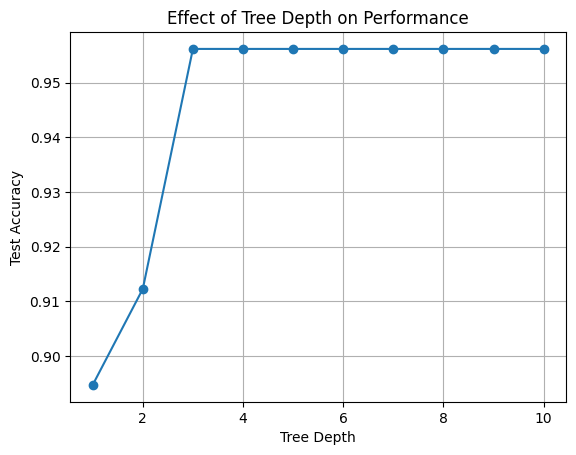

In [21]:
plt.figure()
plt.plot(depths, test_accs, marker='o')

plt.xlabel("Tree Depth")
plt.ylabel("Test Accuracy")
plt.title("Effect of Tree Depth on Performance")

plt.grid()
plt.show()

In [22]:
def bootstrap_sample(X, y):
    n_samples = X.shape[0]
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    
    return X[indices], y[indices]

In [23]:
class BaggingClassifier:
    def __init__(self, n_trees=10, max_depth=5):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.trees = []
    
    def fit(self, X, y):
        self.trees = []
        
        for _ in range(self.n_trees):
            X_sample, y_sample = bootstrap_sample(X, y)
            tree = build_tree(X_sample, y_sample, max_depth=self.max_depth)
            self.trees.append(tree)
    
    def predict(self, X):
        tree_preds = np.array([predict(X, tree) for tree in self.trees])
        
        # Majority voting
        return np.array([
            np.bincount(tree_preds[:, i]).argmax()
            for i in range(X.shape[0])
        ])

In [24]:
# Single Tree
tree = build_tree(X_train, y_train, max_depth=5)
y_pred_tree = predict(X_test, tree)
acc_tree = np.mean(y_pred_tree == y_test)

# Bagging
bagging = BaggingClassifier(n_trees=20, max_depth=5)
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)
acc_bag = np.mean(y_pred_bag == y_test)

print("Single Tree Accuracy:", acc_tree)
print("Bagging Accuracy:", acc_bag)

Single Tree Accuracy: 0.956140350877193
Bagging Accuracy: 0.956140350877193


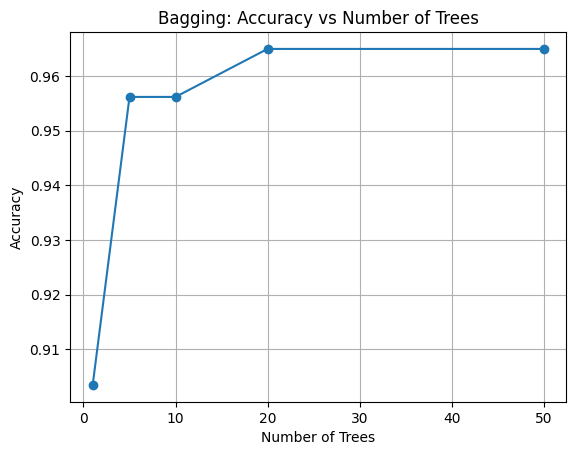

In [25]:
tree_counts = [1, 5, 10, 20, 50]
bag_accs = []

for n in tree_counts:
    bag = BaggingClassifier(n_trees=n, max_depth=5)
    bag.fit(X_train, y_train)
    preds = bag.predict(X_test)
    acc = np.mean(preds == y_test)
    bag_accs.append(acc)

plt.figure()
plt.plot(tree_counts, bag_accs, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Bagging: Accuracy vs Number of Trees")
plt.grid()
plt.show()

In [26]:
def best_split_rf(X, y, max_features):
    best_gain = -1
    best_feature = None
    best_threshold = None
    
    n_features = X.shape[1]
    
    features = np.random.choice(n_features, max_features, replace=False)
    
    for feature in features:
        thresholds = np.unique(X[:, feature])
        
        for threshold in thresholds:
            X_l, y_l, X_r, y_r = split(X, y, feature, threshold)
            
            if len(y_l) == 0 or len(y_r) == 0:
                continue
            
            gain = information_gain(y, y_l, y_r)
            
            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold
    
    return best_feature, best_threshold

In [27]:
def build_tree_rf(X, y, depth=0, max_depth=5, max_features=5):
    if len(np.unique(y)) == 1 or depth >= max_depth:
        return Node(value=np.bincount(y).argmax())
    
    feature, threshold = best_split_rf(X, y, max_features)
    
    if feature is None:
        return Node(value=np.bincount(y).argmax())
    
    X_l, y_l, X_r, y_r = split(X, y, feature, threshold)
    
    left = build_tree_rf(X_l, y_l, depth + 1, max_depth, max_features)
    right = build_tree_rf(X_r, y_r, depth + 1, max_depth, max_features)
    
    return Node(feature, threshold, left, right)

In [28]:
class RandomForestClassifier:
    def __init__(self, n_trees=10, max_depth=5, max_features=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.max_features = max_features
        self.trees = []
    
    def fit(self, X, y):
        self.trees = []
        n_features_total = X.shape[1]
        
        if self.max_features is None:
            self.max_features = int(np.sqrt(n_features_total))
        
        for _ in range(self.n_trees):
            X_sample, y_sample = bootstrap_sample(X, y)
            tree = build_tree_rf(
                X_sample, y_sample,
                max_depth=self.max_depth,
                max_features=self.max_features
            )
            self.trees.append(tree)
    
    def predict(self, X):
        tree_preds = np.array([predict(X, tree) for tree in self.trees])
        
        return np.array([
            np.bincount(tree_preds[:, i]).argmax()
            for i in range(X.shape[0])
        ])

In [29]:
# Random Forest
rf = RandomForestClassifier(n_trees=20, max_depth=5)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = np.mean(y_pred_rf == y_test)

print("Single Tree:", acc_tree)
print("Bagging:", acc_bag)
print("Random Forest:", acc_rf)

Single Tree: 0.956140350877193
Bagging: 0.956140350877193
Random Forest: 0.9649122807017544


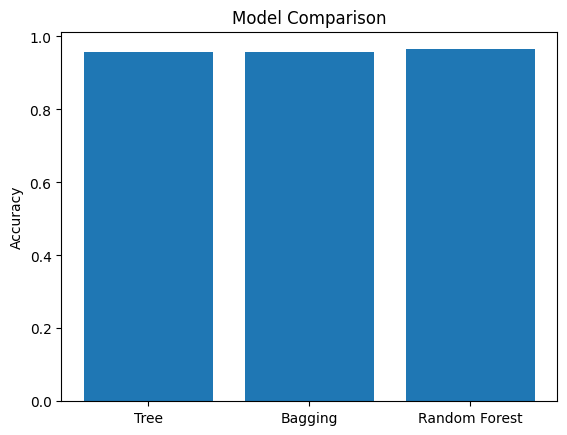

In [30]:
models = ["Tree", "Bagging", "Random Forest"]
accuracies = [acc_tree, acc_bag, acc_rf]

plt.figure()
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [31]:
rf = RandomForestClassifier(
    n_trees=50,
    max_depth=10,
    max_features=5   # force stronger randomness
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = np.mean(y_pred_rf == y_test)

print("Updated Random Forest:", acc_rf)

Updated Random Forest: 0.9736842105263158


In [32]:
# Add noise artificially
X_train_noisy = X_train + np.random.normal(0, 1.0, X_train.shape)
X_test_noisy = X_test + np.random.normal(0, 1.0, X_test.shape)

In [33]:
# Single Tree on Noisy Data
tree_noisy = build_tree(X_train_noisy, y_train, max_depth=5)
y_pred_tree_noisy = predict(X_test_noisy, tree_noisy)
acc_tree_noisy = np.mean(y_pred_tree_noisy == y_test)

print("Single Tree (Noisy):", acc_tree_noisy)

Single Tree (Noisy): 0.8771929824561403


In [34]:
# Bagging on Noisy Data
bag_noisy = BaggingClassifier(n_trees=20, max_depth=5)
bag_noisy.fit(X_train_noisy, y_train)

y_pred_bag_noisy = bag_noisy.predict(X_test_noisy)
acc_bag_noisy = np.mean(y_pred_bag_noisy == y_test)

print("Bagging (Noisy):", acc_bag_noisy)

Bagging (Noisy): 0.9385964912280702


In [35]:
# Random Forest on Noisy Data
rf_noisy = RandomForestClassifier(n_trees=20, max_depth=5, max_features=5)
rf_noisy.fit(X_train_noisy, y_train)

y_pred_rf_noisy = rf_noisy.predict(X_test_noisy)
acc_rf_noisy = np.mean(y_pred_rf_noisy == y_test)

print("Random Forest (Noisy):", acc_rf_noisy)

Random Forest (Noisy): 0.9473684210526315


In [36]:
print("\n--- CLEAN DATA ---")
print("Tree:", acc_tree)
print("Bagging:", acc_bag)
print("Random Forest:", acc_rf)

print("\n--- NOISY DATA ---")
print("Tree:", acc_tree_noisy)
print("Bagging:", acc_bag_noisy)
print("Random Forest:", acc_rf_noisy)


--- CLEAN DATA ---
Tree: 0.956140350877193
Bagging: 0.956140350877193
Random Forest: 0.9736842105263158

--- NOISY DATA ---
Tree: 0.8771929824561403
Bagging: 0.9385964912280702
Random Forest: 0.9473684210526315


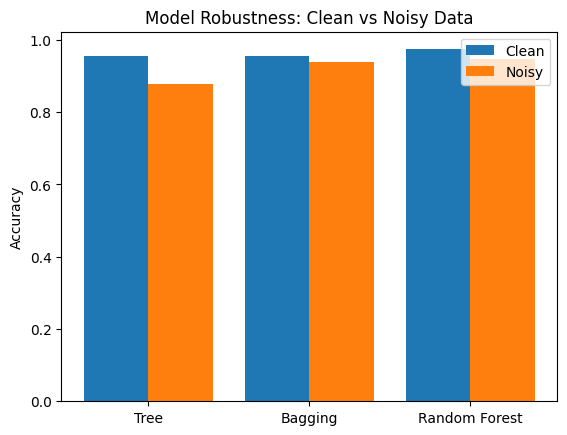

In [37]:
models = ["Tree", "Bagging", "Random Forest"]

clean_accs = [acc_tree, acc_bag, acc_rf]
noisy_accs = [acc_tree_noisy, acc_bag_noisy, acc_rf_noisy]

x = np.arange(len(models))

plt.figure()
plt.bar(x - 0.2, clean_accs, width=0.4, label="Clean")
plt.bar(x + 0.2, noisy_accs, width=0.4, label="Noisy")

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Model Robustness: Clean vs Noisy Data")
plt.legend()

plt.show()

ADABOOST IMPLEMENTATION

In [56]:
# Convert labels to -1 and +1
y_train_boost = np.where(y_train == 0, -1, 1)
y_test_boost = np.where(y_test == 0, -1, 1)

In [57]:
def train_stump(X, y, sample_weights):
    n_samples, n_features = X.shape
    
    best_feature = None
    best_threshold = None
    best_polarity = 1
    min_error = float('inf')
    
    for feature in range(n_features):
        thresholds = np.unique(X[:, feature])
        
        for threshold in thresholds:
            for polarity in [1, -1]:
                
                predictions = np.ones(n_samples)
                if polarity == 1:
                    predictions[X[:, feature] < threshold] = -1
                else:
                    predictions[X[:, feature] < threshold] = 1
                
                misclassified = (predictions != y)
                error = np.sum(sample_weights * misclassified)
                
                if error < min_error:
                    min_error = error
                    best_feature = feature
                    best_threshold = threshold
                    best_polarity = polarity
    
    return best_feature, best_threshold, best_polarity, min_error

In [58]:
class AdaBoost:
    def __init__(self, n_estimators=20):
        self.n_estimators = n_estimators
        self.models = []
        self.alphas = []
    
    def fit(self, X, y):
        n_samples = X.shape[0]
        
        # Initialize weights
        weights = np.ones(n_samples) / n_samples
        
        for _ in range(self.n_estimators):
            feature, threshold, polarity, error = train_stump(X, y, weights)
            
            # Avoid division by zero
            error = max(error, 1e-10)
            
            # Model weight
            alpha = 0.5 * np.log((1 - error) / error)
            
            # Predictions
            predictions = np.ones(n_samples)
            if polarity == 1:
                predictions[X[:, feature] < threshold] = -1
            else:
                predictions[X[:, feature] < threshold] = 1
            
            # Update weights
            weights *= np.exp(-alpha * y * predictions)
            weights /= np.sum(weights)
            
            # Save model
            self.models.append((feature, threshold, polarity))
            self.alphas.append(alpha)
    
    def predict(self, X):
        final_pred = np.zeros(X.shape[0])
        
        for alpha, (feature, threshold, polarity) in zip(self.alphas, self.models):
            predictions = np.ones(X.shape[0])
            
            if polarity == 1:
                predictions[X[:, feature] < threshold] = -1
            else:
                predictions[X[:, feature] < threshold] = 1
            
            final_pred += alpha * predictions
        
        return np.sign(final_pred)

In [59]:
ada = AdaBoost(n_estimators=20)
ada.fit(X_train, y_train_boost)

y_pred_ada = ada.predict(X_test)
acc_ada = np.mean(y_pred_ada == y_test_boost)

print("AdaBoost Accuracy:", acc_ada)

AdaBoost Accuracy: 0.6140350877192983


In [60]:
def build_tree_reg(X, y, depth=0, max_depth=3):
    if depth >= max_depth or len(y) <= 1:
        return Node(value=np.mean(y))
    
    feature, threshold = best_split(X, y)
    
    if feature is None:
        return Node(value=np.mean(y))
    
    X_l, y_l, X_r, y_r = split(X, y, feature, threshold)
    
    left = build_tree_reg(X_l, y_l, depth + 1, max_depth)
    right = build_tree_reg(X_r, y_r, depth + 1, max_depth)
    
    return Node(feature, threshold, left, right)

In [61]:
class GradientBoosting:
    def __init__(self, n_estimators=20, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.models = []
    
    def fit(self, X, y):
        self.initial_pred = np.mean(y)
        y_pred = np.full(len(y), self.initial_pred)
        
        for _ in range(self.n_estimators):
            residuals = y - y_pred
            
            tree = build_tree_reg(X, residuals, max_depth=self.max_depth)
            
            pred = np.array([predict_single(x, tree) for x in X])
            
            y_pred += self.learning_rate * pred
            self.models.append(tree)
    
    def predict_gb(self, X):
        y_pred = np.full(X.shape[0], self.initial_pred)
        
        for tree in self.models:
            pred = np.array([predict_single(x, tree) for x in X])
            y_pred += self.learning_rate * pred
        
        return (y_pred > 0.5).astype(int)

In [62]:
gb = GradientBoosting(n_estimators=20, learning_rate=0.1, max_depth=3)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict_gb(X_test)
acc_gb = np.mean(y_pred_gb == y_test)

print("Gradient Boosting Accuracy:", acc_gb)

Gradient Boosting Accuracy: 0.956140350877193


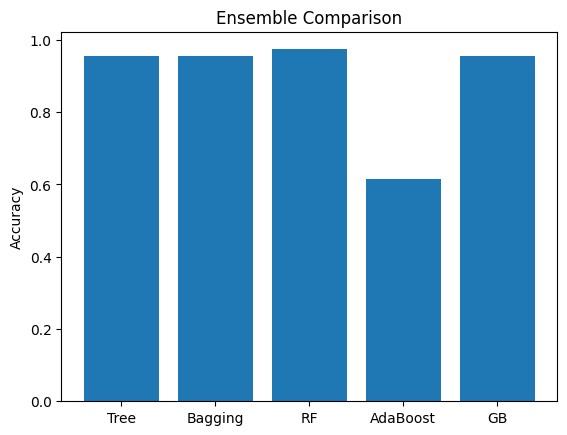

In [63]:
models = ["Tree", "Bagging", "RF", "AdaBoost", "GB"]
accuracies = [acc_tree, acc_bag, acc_rf, acc_ada, acc_gb]

plt.figure()
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Ensemble Comparison")
plt.show()